# Transfer Visualizations

t-SNE visualizations of transfer experiments.

In [ ]:
import pickle
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import jensenshannon, cdist

## Load Data

In [2]:
agent_map_f = [
    "F only",
    "... → E",
    "... → F"
]

agent_map_g = [
    "G only",
    "... → F",
    "... → G"
]

with open("../trajs/regf_trajs_indist_enc.pkl",'rb') as f:
    df_f_indist: pd.DataFrame = pickle.load(f)
with open("../trajs/regf_trajs_outofdist_enc.pkl",'rb') as f:
    df_f_outdist: pd.DataFrame = pickle.load(f)
with open("../trajs/regg_trajs_indist_enc.pkl",'rb') as f:
    df_g_indist: pd.DataFrame = pickle.load(f)
with open("../trajs/regg_trajs_outofdist_enc.pkl",'rb') as f:
    df_g_outdist: pd.DataFrame = pickle.load(f)

def preprocess(df: pd.DataFrame):
    # normalize depth
    df["progress"] = df["depth"].transform(lambda x: x / x.max())

    # drop agent 0
    # df.drop(["action1_0", "action2_0", "value_0"], axis=1, inplace=True)
    # df.rename(columns=lambda name: name if (not name[-1].isdigit()) else (name[:-1]+f"{int(name[-1])-1}"), inplace=True)

preprocess(df_f_indist)
preprocess(df_f_outdist)
preprocess(df_g_indist)
preprocess(df_g_outdist)

## Numerical Analysis

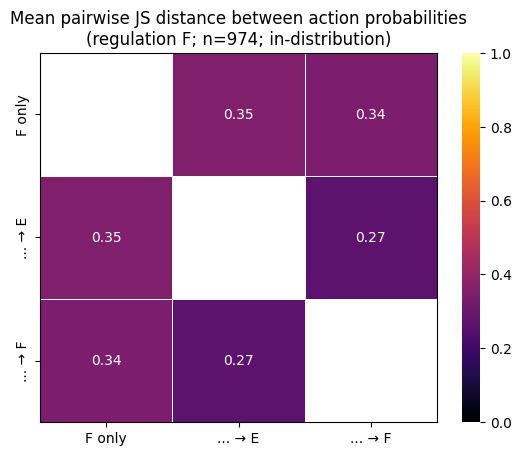

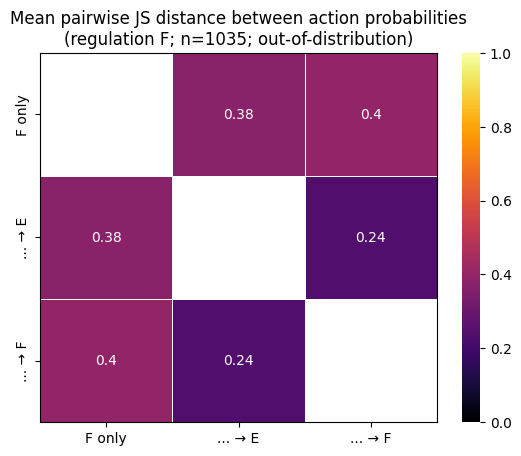

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


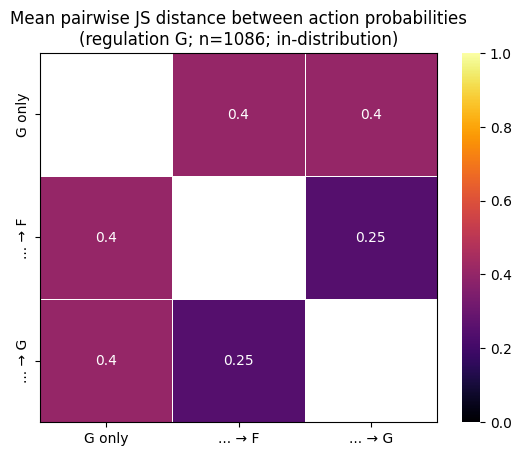

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


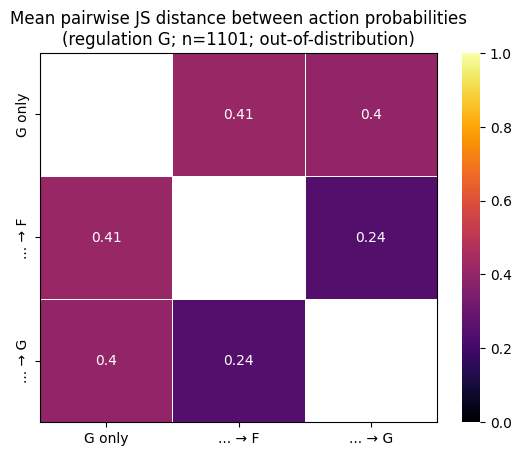

In [3]:
# mean js distance between action probs
def mean_dist_action(df, labels, reg, in_dist):
    distance_matrix = np.identity(len(labels))
    for i in range(len(labels)):
        for j in range(i):
            distance_matrix[i][j] = np.array([l for l in filter(lambda v: v==v, np.concat((
                np.array([
                    jensenshannon(df[f"action1_{i}"].values[k].clip(0,1), df[f"action1_{j}"].values[k].clip(0,1))
                for k in range(len(df))]),
                np.array([
                    jensenshannon(df[f"action2_{i}"].values[k].clip(0,1), df[f"action2_{j}"].values[k].clip(0,1))
                for k in range(len(df))])
            )))]).mean()
    distance_matrix = distance_matrix + distance_matrix.T
    np.fill_diagonal(distance_matrix, np.nan)

    ax = sns.heatmap(
        distance_matrix,
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2g",
        cmap="inferno",
        linewidth=0.5,
        xticklabels=labels,
        yticklabels=labels
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    plt.title(
        f"Mean pairwise JS distance between action probabilities\n(regulation {reg}; n={len(df)}; {'in' if in_dist else 'out-of'}-distribution)"
    )
    plt.show()

mean_dist_action(df_f_indist, agent_map_f, "F", True)
mean_dist_action(df_f_outdist, agent_map_f, "F", False)
mean_dist_action(df_g_indist, agent_map_g, "G", True)
mean_dist_action(df_g_outdist, agent_map_g, "G", False)

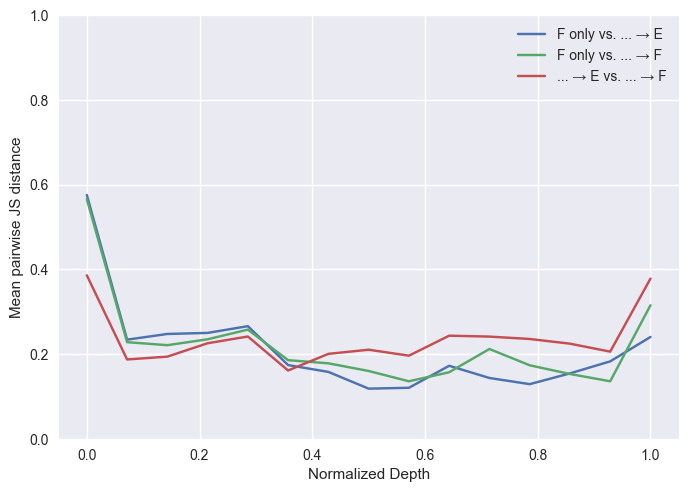

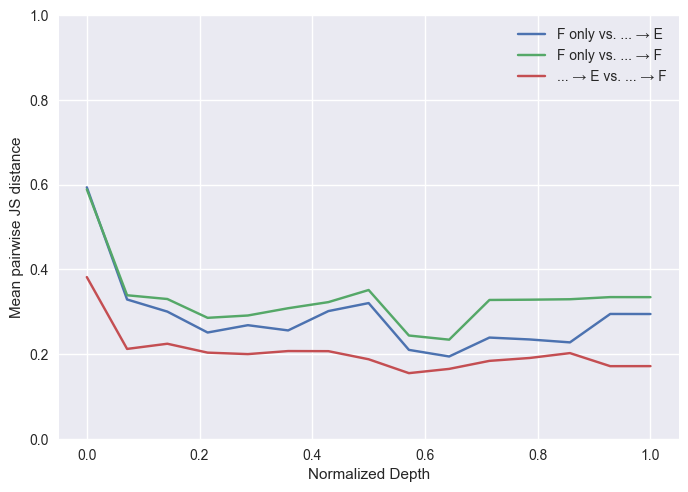

c:\Users\Thoma\OneDrive\Documenten\GitHub\vgc-bench\.venv\Lib\site-packages\scipy\spatial\distance.py:1290: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


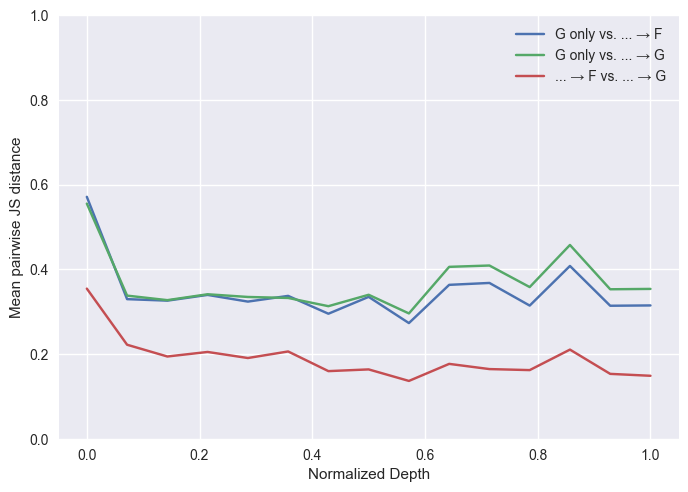

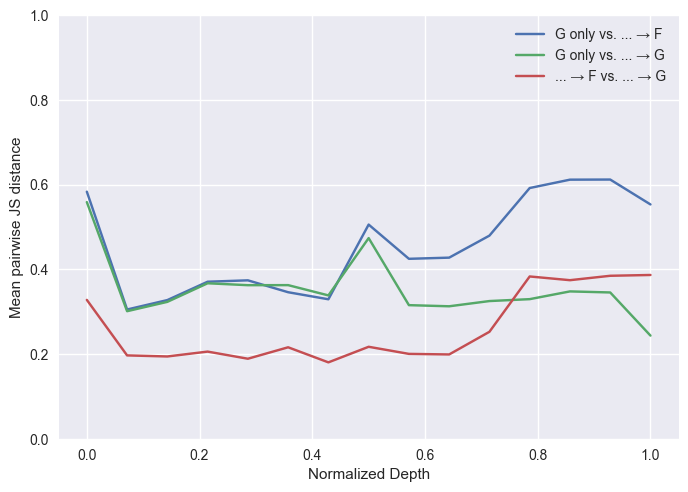

In [3]:
def mean_dist_action_depth(df: pd.DataFrame, labels, reg, in_dist):    
    depths = np.linspace(0, 1, num=15, endpoint=True)
    for i in range(len(labels)):
        for j in range(i):
            plt.plot(
                depths,
                [np.array([l for l in filter(lambda v: v==v, np.concat((
                    np.array([
                        jensenshannon(
                            df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"action1_{i}"].values[k].clip(0,1),
                            df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"action1_{j}"].values[k].clip(0,1)
                        )
                    for k in range(len(df[(d <= df["progress"]) & (df["progress"] < d+0.05)]))]),
                    np.array([
                        jensenshannon(
                            df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"action2_{i}"].values[k].clip(0,1),
                            df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"action2_{j}"].values[k].clip(0,1)
                        )
                    for k in range(len(df[(d <= df["progress"]) & (df["progress"] < d+0.05)]))])
                )))]).mean() for d in depths],
                label=f"{labels[j]} vs. {labels[i]}"
            )
    plt.legend()
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean pairwise JS distance")
    # plt.xlim(0, 1)
    plt.ylim(0, 1)
    # plt.title(
    #     f"Mean pairwise JS distance between action probabilities over normalized depth\n\
    #     (regulation {reg}; n={len(df)}; {'in' if in_dist else 'out-of'}-distribution)"
    # )
    plt.show()

plt.style.use('seaborn-v0_8')
mean_dist_action_depth(df_f_indist, agent_map_f, "F", True)
mean_dist_action_depth(df_f_outdist, agent_map_f, "F", False)
mean_dist_action_depth(df_g_indist, agent_map_g, "G", True)
mean_dist_action_depth(df_g_outdist, agent_map_g, "G", False)

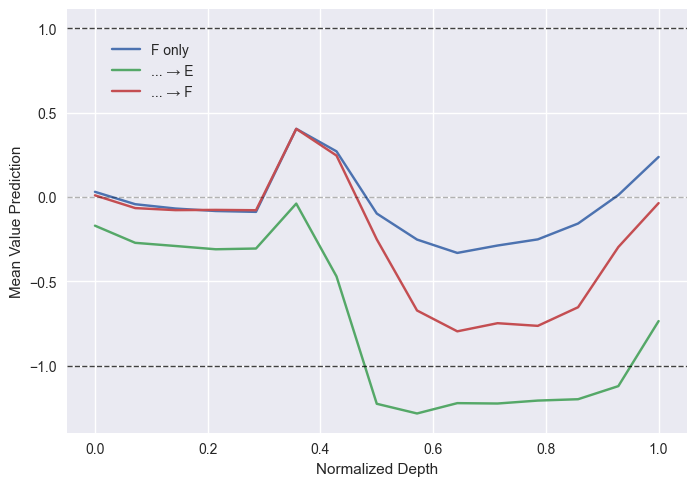

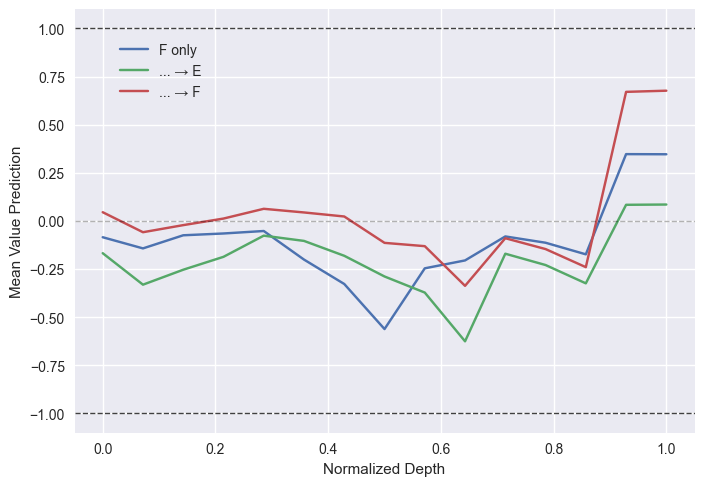

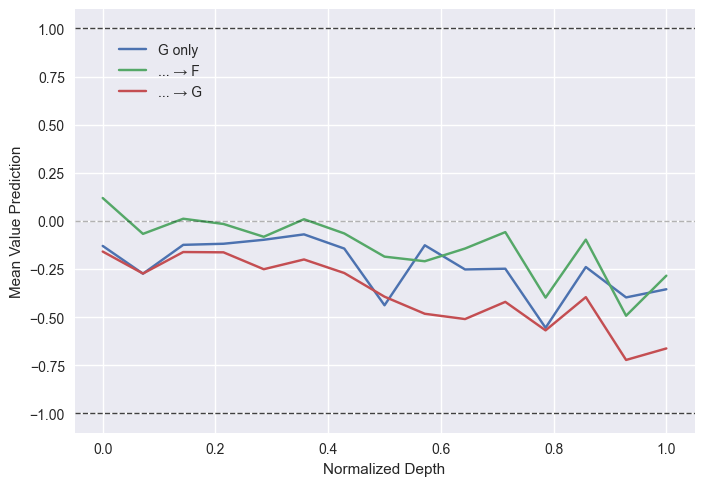

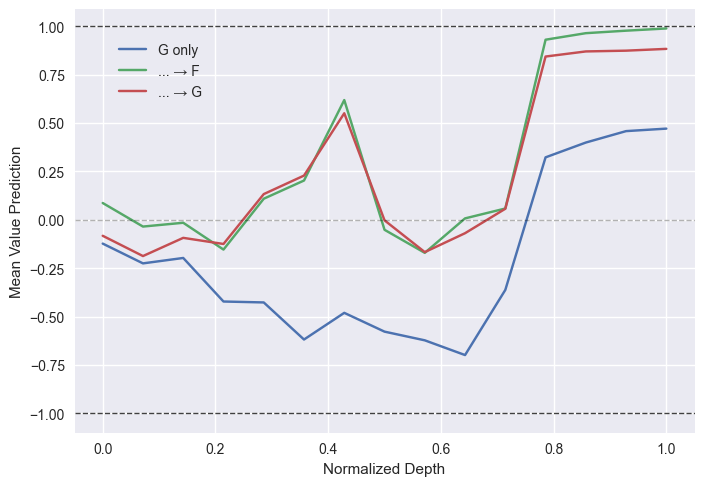

In [4]:
def mean_val_depth(df: pd.DataFrame, labels, reg, in_dist):
    depths = np.linspace(0, 1, num=15, endpoint=True)
    for i in range(len(labels)):
        plt.plot(
            depths,
            [df[(d <= df["progress"]) & (df["progress"] < d+0.05)][f"value_{i}"].mean() for d in depths],
            label=labels[i]
        )
    plt.xlabel("Normalized Depth")
    plt.ylabel("Mean Value Prediction")
    plt.axhline(y=0, linestyle='--', linewidth=1, color=(0, 0, 0, 0.3))
    plt.axhline(y=-1, linestyle='--', linewidth=1, color=(0, 0, 0, 0.75))
    plt.axhline(y=1, linestyle='--', linewidth=1, color=(0, 0, 0, 0.75))
    # plt.title(
    #     f"Mean value prediction over normalized depth (regulation {reg}; n={len(df)}; {'in' if in_dist else 'out-of'}-distribution)"
    # )
    plt.legend(loc=1, bbox_to_anchor=(0.225,0.95))
    plt.show()

plt.style.use('seaborn-v0_8')
mean_val_depth(df_f_indist, agent_map_f, "F", True)
mean_val_depth(df_f_outdist, agent_map_f, "F", False)
mean_val_depth(df_g_indist, agent_map_g, "G", True)
mean_val_depth(df_g_outdist, agent_map_g, "G", False)

In [36]:
for i in range(len(agent_map_f)):
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_f_indist[f"logits_{i}"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_f[i]}: {pr} (in-distribution)")
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_f_outdist[f"logits_{i}"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_f[i]}: {pr} (out-of-distribution)")

print()
for i in range(len(agent_map_g)):
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_g_indist[f"logits_{i}"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_g[i]}: {pr} (in-distribution)")
    eigvals = np.linalg.eigvalsh(np.cov(np.vstack(df_g_outdist[f"logits_{i}"]).T)) # type: ignore
    pr = eigvals.sum()**2 / np.square(eigvals).sum()
    print(f"Participation Ratio for {agent_map_g[i]}: {pr} (out-of-distribution)")
# significantly lower PR for the transferred agent -> representation collapse

Participation Ratio for F only: 6.621322558776161 (in-distribution)
Participation Ratio for F only: 5.788127591696826 (out-of-distribution)
Participation Ratio for ... → E: 6.2397716702661485 (in-distribution)
Participation Ratio for ... → E: 4.898130336720081 (out-of-distribution)
Participation Ratio for ... → F: 6.159942261052667 (in-distribution)
Participation Ratio for ... → F: 5.005363485800187 (out-of-distribution)

Participation Ratio for G only: 7.982782958166494 (in-distribution)
Participation Ratio for G only: 7.049559318084975 (out-of-distribution)
Participation Ratio for ... → F: 6.097624928764128 (in-distribution)
Participation Ratio for ... → F: 5.743827634315657 (out-of-distribution)
Participation Ratio for ... → G: 5.829181937911121 (in-distribution)
Participation Ratio for ... → G: 5.628133689513519 (out-of-distribution)


## t-SNE

In [ ]:
RANDOM_STATE = 42

def tnse_encode(df: pd.DataFrame) -> np.ndarray:
    X = np.vstack([np.array([i for i in df[c].to_numpy()]).squeeze(1) for c in df.columns])

    # PCA preprocessing
    pca = PCA(n_components=50, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=RANDOM_STATE,
        verbose=1
    )
    return tsne.fit_transform(X_pca)

def filter_columns(df: pd.DataFrame, agents: list[int]) -> pd.DataFrame:
    mask = []
    for i in agents:
        mask.append(f"logits_{i}")
    return df[mask]

tsne_f_indist = tnse_encode(filter_columns(df_f_indist, [0, 1, 2]))
tsne_f_outdist = tnse_encode(filter_columns(df_f_outdist, [0, 1, 2]))
tsne_g_indist = tnse_encode(filter_columns(df_g_indist, [0, 1, 2]))
tsne_g_outdist = tnse_encode(filter_columns(df_g_outdist, [0, 1, 2]))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2922 samples in 0.001s...
[t-SNE] Computed neighbors for 2922 samples in 2.318s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2922
[t-SNE] Computed conditional probabilities for sample 2000 / 2922
[t-SNE] Computed conditional probabilities for sample 2922 / 2922
[t-SNE] Mean sigma: 22.676763
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.722214
[t-SNE] KL divergence after 1000 iterations: 0.584126
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3105 samples in 0.000s...
[t-SNE] Computed neighbors for 3105 samples in 0.085s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3105
[t-SNE] Computed conditional probabilities for sample 2000 / 3105
[t-SNE] Computed conditional probabilities for sample 3000 / 3105
[t-SNE] Computed conditional probabilities for sample 3105 / 3105
[t-SNE] Mean sigma: 21.571705
[t-SNE] KL divergence after 250 iterations with early exaggerati

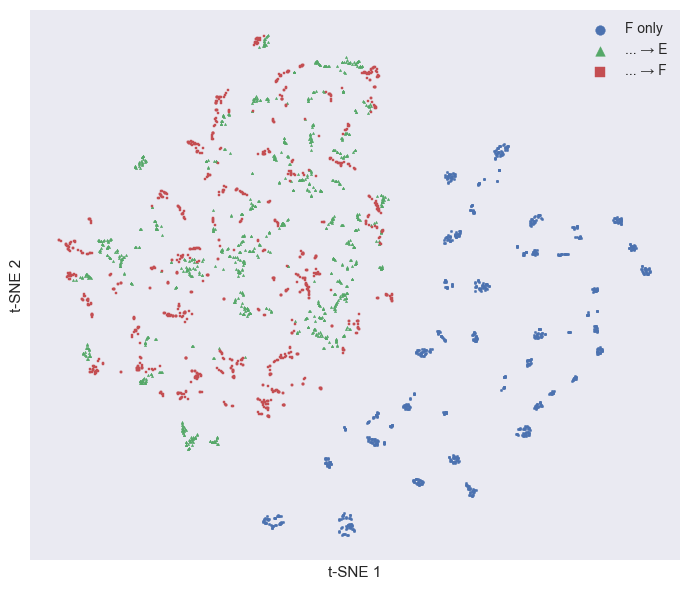

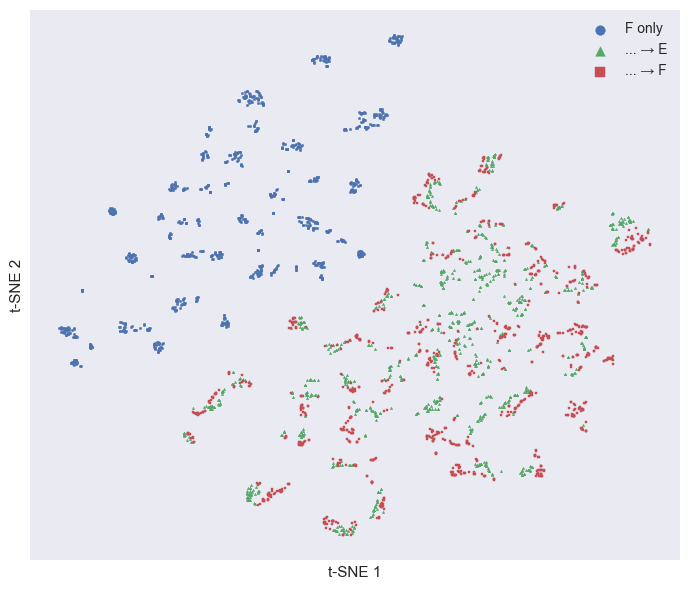

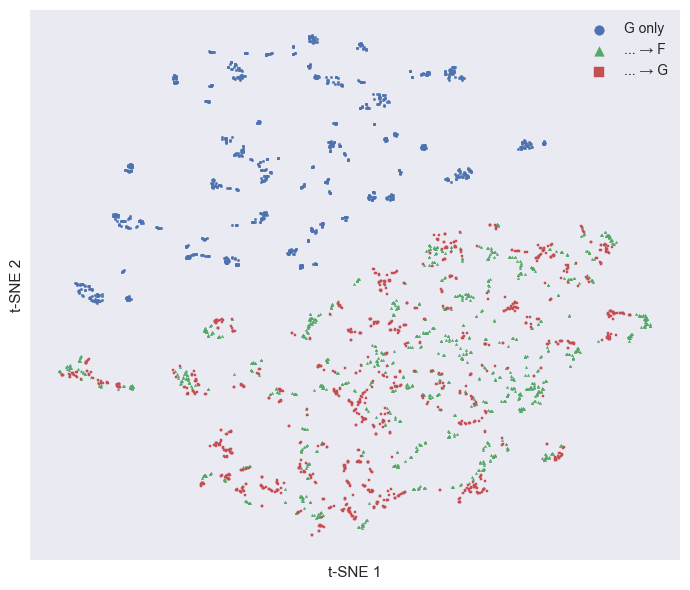

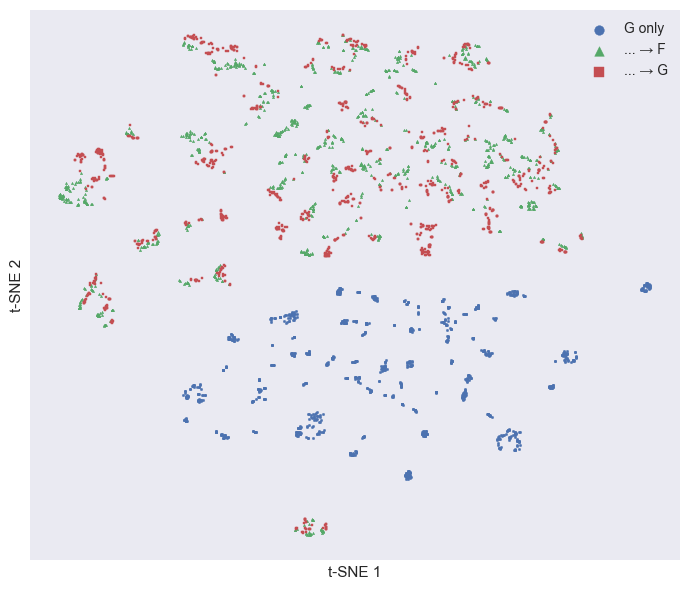

In [5]:
def plot_tnse(df:pd.DataFrame, X_tsne: np.ndarray, agent_map: list[str]):
    plt.figure(figsize=(7, 6))

    n = len(df)
    emb_0  = X_tsne[:n]
    emb_1 = X_tsne[n:2*n]
    emb_2  = X_tsne[2*n:]

    plt.scatter(emb_0[:, 0], emb_0[:, 1], s=3, marker='o', label=agent_map[0])
    plt.scatter(emb_1[:, 0], emb_1[:, 1], s=3, marker='^', label=agent_map[1])
    plt.scatter(emb_2[:, 0], emb_2[:, 1], s=3, marker='s', label=agent_map[2])

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.legend(markerscale=4)
    plt.tight_layout()
    plt.show()

plt.style.use('seaborn-v0_8')
plot_tnse(df_f_indist, tsne_f_indist, agent_map_f)
plot_tnse(df_f_outdist, tsne_f_outdist, agent_map_f)
plot_tnse(df_g_indist, tsne_g_indist, agent_map_g)
plot_tnse(df_g_outdist, tsne_g_outdist, agent_map_g)

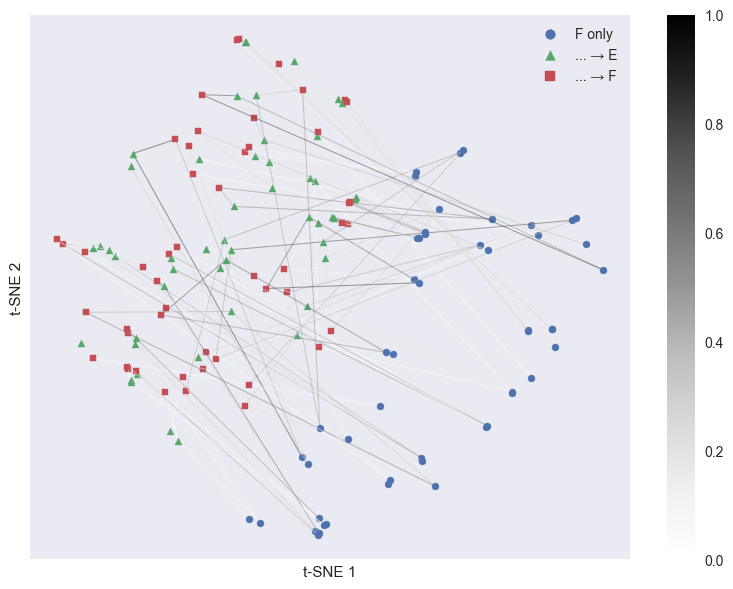

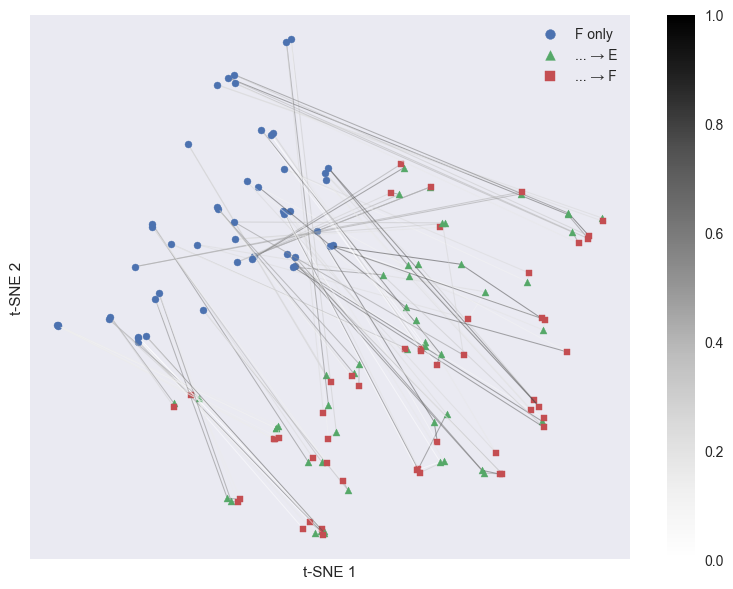

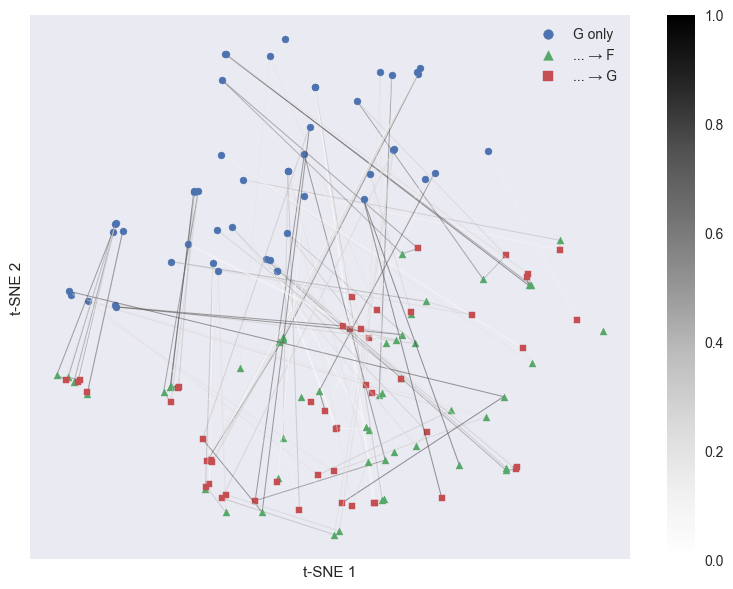

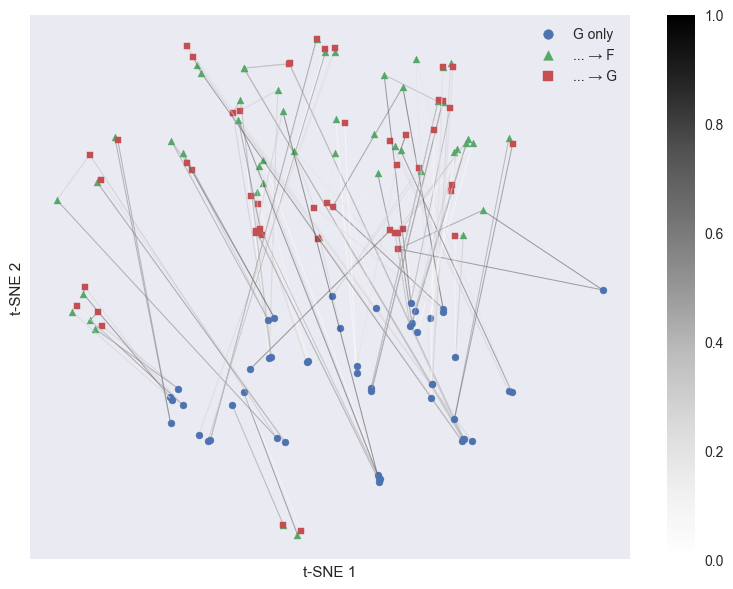

In [13]:
def plot_tnse(df: pd.DataFrame, X_tsne: np.ndarray, agent_map: list[str]):
    plt.figure(figsize=(8, 6))

    n = len(df)
    n_plot = 50
    idx = np.random.choice(n, n_plot, replace=False)

    emb_0  = X_tsne[:n]
    emb_1 = X_tsne[n:2*n]
    emb_2  = X_tsne[2*n:]

    cmap = plt.colormaps['Grays']
    colors = sns.color_palette(as_cmap=True)

    for j in idx:

        pts = np.vstack([
            emb_0[j],
            emb_1[j],
            emb_2[j]
        ])
        logits1 = np.array([i for i in df.iloc[j][["action1_0", "action1_1", "action1_2"]].to_numpy()])
        logits2 = np.array([i for i in df.iloc[j][["action2_0", "action2_1", "action2_2"]].to_numpy()])
        dists = (cdist(logits1, logits1, 'jensenshannon') + cdist(logits2, logits2, 'jensenshannon')) / 2

        # connect triplet
        plt.plot(
            pts[0:2,0],
            pts[0:2,1],
            c=cmap(dists[0,1]),
            alpha=0.5,
            linewidth=0.75,
            zorder=1
        )
        plt.plot(
            pts[1:3,0],
            pts[1:3,1],
            c=cmap(dists[0,2]),
            alpha=0.5,
            linewidth=0.75,
            zorder=1
        )
        plt.plot(
            pts[::2,0],
            pts[::2,1],
            c=cmap(dists[1,2]),
            alpha=0.5,
            linewidth=0.75,
            zorder=1
        )

        # draw points
        plt.scatter(*emb_0[j],  marker='o', color=colors[0], s=25)
        plt.scatter(*emb_1[j], marker='^', color=colors[1], s=25)
        plt.scatter(*emb_2[j],  marker='s', color=colors[2], s=25)

    # legend
    plt.scatter([], [], marker='o', color=colors[0], label=agent_map[0])
    plt.scatter([], [], marker='^', color=colors[1], label=agent_map[1])
    plt.scatter([], [], marker='s', color=colors[2], label=agent_map[2])
    plt.colorbar()

    plt.xlabel("t-SNE 1")
    plt.xticks([])
    plt.ylabel("t-SNE 2")
    plt.yticks([])
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.style.use('seaborn-v0_8')
plot_tnse(df_f_indist, tsne_f_indist, agent_map_f)
plot_tnse(df_f_outdist, tsne_f_outdist, agent_map_f)
plot_tnse(df_g_indist, tsne_g_indist, agent_map_g)
plot_tnse(df_g_outdist, tsne_g_outdist, agent_map_g)